# Chocolate Sales in 2022-2023

Today we're going to do some analysises about the dataset containing Chocolate Sales during the period of 2022 and 2023. Before that we need to prepare dataset, process null values, do encoding for specific features if necessary. Saying shortly, we're doing EDA.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv')
data = df.copy()

In [5]:
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


**According to the dataset description, we have:**
1. Order_ID — Unique identifier for each order
2. Product — Chocolate product name
3. Country — Country of sale
4. Channel — Sales channel (Retail / Online / Wholesale)
5. Salesperson — Sales representative handling the order
6. Order_Date — Date the order was placed
7. Discount_Pct — Discount applied to the order (%)
8. Price_per_Box — Price per box after discount (USD)
9. Marketing_Spend — Marketing budget allocated around the order (USD)
10. Boxes_Shipped — Number of boxes shipped for the order
11. Amount — Total order value (Boxes_Shipped × Price_per_Box)

Let's see the dataset's information.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


The total amount of rows is $200000$, for columns there are $11$ features. For "Order_Date", "Discount_Pct", "Marketing_Spend" there are null values which should be processed.

We see that some features should be converted to another types. For instance, "Order_Date" from object to Datetime, "Amount" from object to float64.

In [7]:
df.shape # total of rows, columns

(200000, 11)

In [8]:
df.columns #column names

Index(['Order_ID', 'Product', 'Country', 'Channel', 'Salesperson',
       'Order_Date', 'Discount_Pct', 'Price_per_Box', 'Marketing_Spend',
       'Boxes_Shipped', 'Amount'],
      dtype='object')

Let's convert to another types for "Order_Date" and "Amount" before using df.describe(). 

In [9]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed') # several dates are mixed, so we use format='mixed' to solve this problem

But it's interesting that we have a symbol '$' in "Amount", although we can't see it. Let's check before processing.

In [10]:
df[df['Amount'].apply(lambda x: '$' in str(x))]

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
12,ORD-185273,Milk Classic Bar,Australia,Retail,Lucas Walker,2022-05-20,11.1,13.45,58.25,32,$383.66
157,ORD-125198,Mint Dark Bar,Australia,Retail,Priya Sharma,2022-04-03,4.9,3.47,70.87,56,$172.89
391,ORD-186735,Almond Crunch Bar,Australia,Retail,Arjun Mehta,2023-03-12,11.3,4.19,42.95,157,$567.88
467,ORD-145804,Mixed Assortment Box,Brazil,Retail,Rohan Patel,2023-05-08,15.9,2.80,99.19,317,$776.76
506,ORD-007560,Hazelnut Milk Bar,Germany,Retail,Emily Clarke,2023-11-21,16.4,2.86,93.30,149,$354.41
...,...,...,...,...,...,...,...,...,...,...,...
199600,ORD-108624,Milk Classic Bar,Brazil,Retail,Arjun Mehta,2023-09-11,12.3,2.92,126.97,190,$504.58
199854,ORD-031142,Salted Caramel Bar,Australia,Wholesale,Michael Johnson,2022-12-27,14.8,3.12,116.76,271,$754.73
199895,ORD-197764,70% Dark Bar,Australia,Retail,Carlos Mendez,2023-07-02,8.4,4.13,82.93,71,$240.92
199946,ORD-196107,Choco Coins Bag,Japan,Wholesale,Rafael Oliveira,2023-12-25,17.2,2.97,43.23,308,$753.31


So we need to delete '$'.

In [11]:
df['Amount'] = df['Amount'].str.replace('$', '', regex=False).astype('float64')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Order_ID         200000 non-null  object        
 1   Product          200000 non-null  object        
 2   Country          200000 non-null  object        
 3   Channel          200000 non-null  object        
 4   Salesperson      200000 non-null  object        
 5   Order_Date       199563 non-null  datetime64[ns]
 6   Discount_Pct     199511 non-null  float64       
 7   Price_per_Box    199543 non-null  float64       
 8   Marketing_Spend  199539 non-null  float64       
 9   Boxes_Shipped    200000 non-null  int64         
 10  Amount           200000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 16.8+ MB


In [13]:
df.describe()

,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
count,199563,199511.000000,199543.000000,199539.000000,200000.000000,200000.000000
mean,2022-12-30 11:18:44.198373632,13.107457,5.911507,95.450141,139.584105,512.861975
min,2022-01-01 00:00:00,0.000000,2.040000,4.300000,-1642.000000,28.810000
25%,2022-07-01 00:00:00,8.300000,2.950000,52.270000,67.000000,287.380000
50%,2022-12-30 00:00:00,12.600000,3.280000,78.850000,113.000000,417.295000
75%,2023-07-01 00:00:00,17.500000,4.570000,118.710000,180.000000,622.520000
max,2023-12-31 00:00:00,38.300000,21.650000,798.222443,3811.000000,12138.090000
std,NaN,6.374477,4.954976,66.243760,118.665393,365.476774


Let's check for nulls and duplicated rows.

In [14]:
df.isna().sum()

Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

Since we have only nulls for "Order_Date", "Discount_Pct", "Price_per_Box" and "Marketing_Spend", and without duplicated rows, we'll see the percentage of nulls.

In [16]:
print(df['Order_Date'].isna().mean() * 100)
print(df['Discount_Pct'].isna().mean() * 100)
print(df['Price_per_Box'].isna().mean() * 100)
print(df['Marketing_Spend'].isna().mean() * 100)

0.2185
0.24450000000000002
0.2285
0.2305


We calculated roughly **0.2%** missing values (e.g., 0.2185%). While this is a very tiny percentage and we could safely drop these rows, we will stick to our original consideration to impute them to retain as much data as possible. Since it's the sales, we will set markers for rows in "Order_Date" before filling fake dates (mode), and for the rest columns we'll fill with median values.

In [17]:
df['Order_Date_missing'] = df['Order_Date'].isna()
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])

In [18]:
median_columns = ['Discount_Pct', 'Price_per_Box', 'Marketing_Spend']
df[median_columns] = df[median_columns].fillna(df[median_columns].median())

In [19]:
df.isna().sum()

Order_ID              0
Product               0
Country               0
Channel               0
Salesperson           0
Order_Date            0
Discount_Pct          0
Price_per_Box         0
Marketing_Spend       0
Boxes_Shipped         0
Amount                0
Order_Date_missing    0
dtype: int64

We processed some nulls for 4 columns and engineered some new features, let's see if there are correlations between features which are only numeric.

In [20]:
# Making feature engineering
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['DayOfWeek'] = df['Order_Date'].dt.day_name()
df['Quarter'] = df['Order_Date'].dt.quarter

In [21]:
# Creating a feature to see average price per box before discount
df['Original_Price_per_Box'] = df['Price_per_Box'] / (1 - (df['Discount_Pct']/100))

In [22]:
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount,Order_Date_missing,Year,Month,DayOfWeek,Quarter,Original_Price_per_Box
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31,False,2022,12,Sunday,4,14.217617
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91,False,2023,3,Tuesday,1,3.642384
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.70,False,2023,12,Thursday,4,19.148265
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27,False,2023,12,Monday,4,3.129412
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69,False,2023,8,Friday,3,2.876569


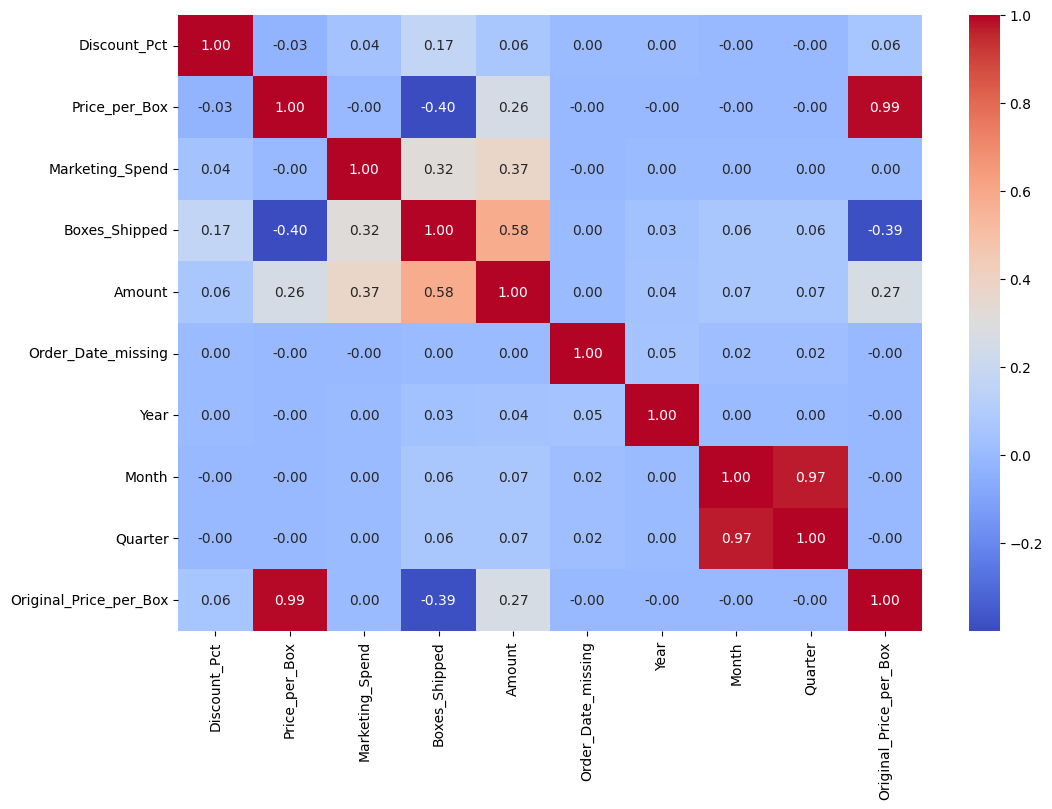

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

From the correlation visualization we can see that the most correlated features are the ones between "Boxed_Shipped" and "Amount", the most negative correlation are between "Price_per_Box" and "Boxes_Shipped". 

Let's see all numeric features at once in the histogram to find out the distribution, outliers, skews.

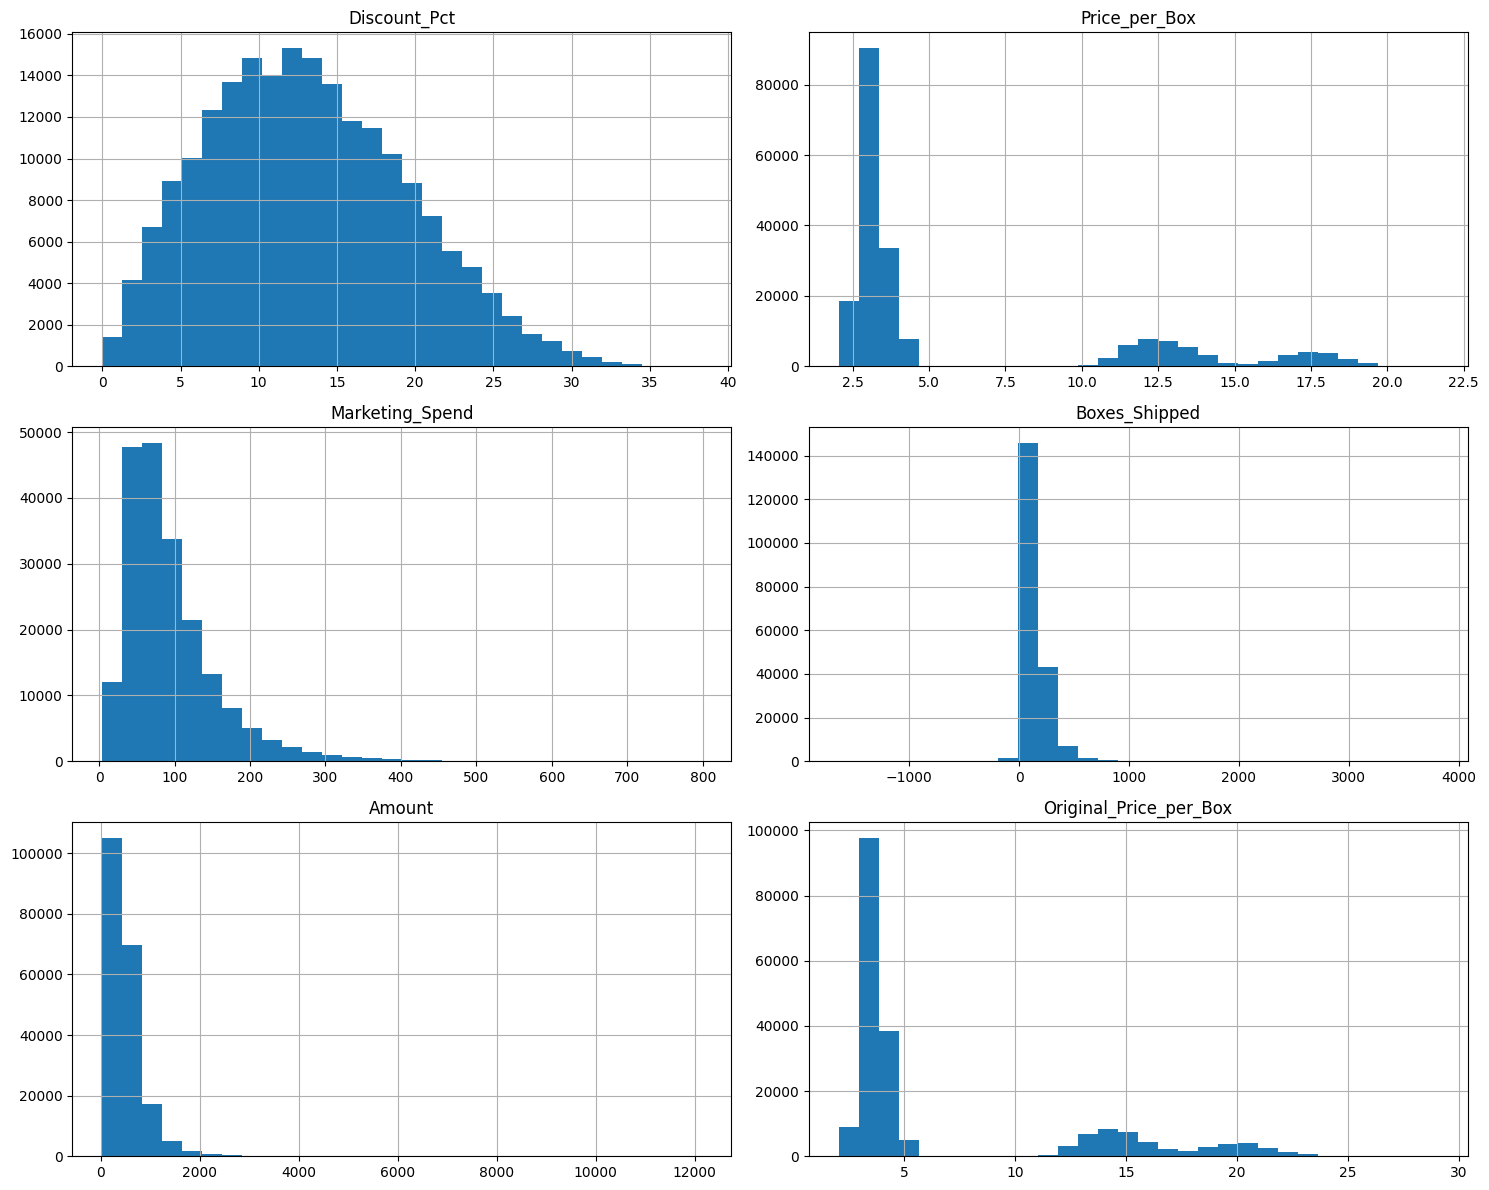

In [24]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_columns].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

Let's analyze each one of the visualization:
1. **Discount_Pct**: supposedly it's unimodal distribution, slightly right-skewed, most discounts are between $7$% and $17$%. No obvious extreme outliers, so we can conclude that the variable has a reasonably smooth distribution, mean and median should be fairly close.
2.  **Price_per_Box**: strongly right-skewed, appears to have multiply peaks (around $3-4$, $12-14$, $17-19$). It means this is not normally distributed, and the peak may indicate different product categories.
3.  **Marketing_Spend**: right-skewed, it has a long tail extending to high values. it concluded that it might contain high-value outliers and log-trasformation may improve the distribution.
4.  **Boxes_Shipped**: extremely concentrated near small values, a long right tail, even the x-axis extends into negative values.
5.  **Amount**: right-skewed, long tail reaches very large amounts, but most transactions are relatively small. With that being said it's a typical business data, mean will be much larger than median, and log transformation is worth considering.

### Categorical Exploratory Data Analysis
Now that we have explored the numeric distributions, let's analyze how sales perform across different categorical dimensions like Country, Sales Channel, and Products.

/tmp/ipykernel_58/3316569006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x='Country', y='Amount', estimator=sum, errorbar=None, palette='viridis')
/tmp/ipykernel_58/3316569006.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='Channel', y='Amount', estimator=sum, errorbar=None, palette='magma')


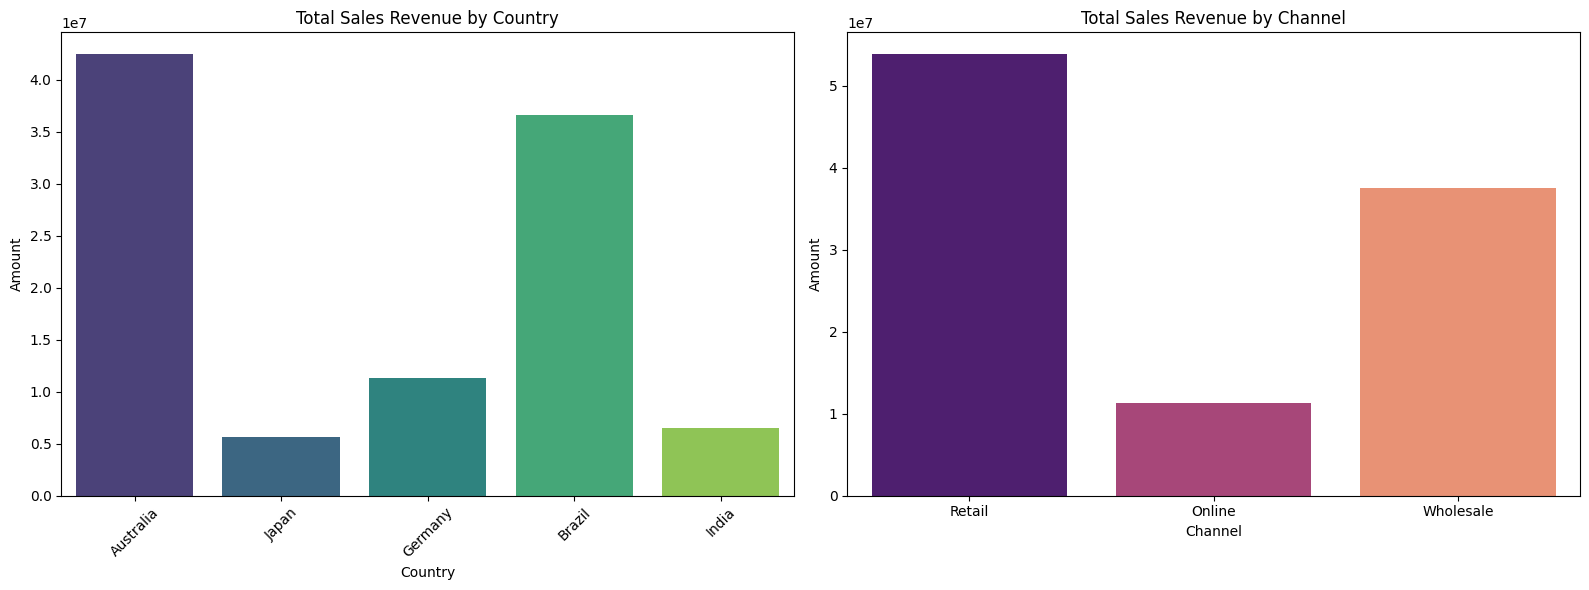

In [25]:
figure, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], data=df, x='Country', y='Amount', estimator=sum, errorbar=None, palette='viridis')
axes[0].set_title('Total Sales Revenue by Country')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], data=df, x='Channel', y='Amount', estimator=sum, errorbar=None, palette='magma')
axes[1].set_title('Total Sales Revenue by Channel')

plt.tight_layout()
plt.show()

### Key findings & insights from EDA
1. Our correlation heatmap reveals a strong negative correlation between `Price_per_Box` and `Boxes_Shipped`. This confirms the economic principle of elasticity: as price decreases, volume shipped increases.
2. The `Amount` feature is heavily correlated with `Boxes_Shipped`, indicating that driving volume (rather than simply increasing price) is the primary engine for total revenue growth.
3. The dataset is highly complete, with only ~0.2% missing values across key operational metrics, which were successfully imputed to maintain the structural integrity of the time-series analysis.

### Hypothesis Formulation
To move beyond descriptive statistics into inferential analysis, we propose the following three hypotheses regarding our sales operations:

* **Hypothesis 1**: higher discount percentages result in a statistically significant increase in the number of `Boxes_Shipped`.
* **Hypothesis 2**: the *Online* sales channel generates a significantly higher average `Amount` per order compared to the *Retail* channel.
* **Hypothesis 3**: there is a significant positive correlation between `Marketing_Spend` and total order `Amount`.

### Significance Testing (Hypothesis 2)
1. **$H_0$**: there is no difference in the average order Amount between Online and Retail channels.
2. **$H_1$**: there is a significant difference in the average order Amount between Online and Retail channels.

In [27]:
from scipy import stats

online_sales = df[df['Channel'] == 'Online']['Amount'].dropna()
retail_sales = df[df['Channel'] == 'Retail']['Amount'].dropna()

t_stat, p_val = stats.ttest_ind(online_sales, retail_sales, equal_var=False)

print(f"Average Online Order Amount: ${online_sales.mean():.2f}")
print(f"Average Retail Order Amount: ${retail_sales.mean():.2f}")
print("-" * 30)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("\nConclusion: reject the Null Hypothesis. There is a statistically significant difference in order amounts between channels.")
else:
    print("\nConclusion: fail to reject the Null Hypothesis. No significant difference found.")

Average Online Order Amount: $465.85
Average Retail Order Amount: $461.73
------------------------------
T-Statistic: 1.8109
P-Value: 7.0171e-02

Conclusion: fail to reject the Null Hypothesis. No significant difference found.


This test allows the business to mathematically validate if allocating resources to expand the Online platform yields better cart values than expanding physical Retail footprints.

### Conclusion & Next Steps
**Conclusion:**
this analysis successfully cleaned the 2022-2023 Chocolate Sales data, engineered new temporal features, and established clear operational baselines. We discovered that pricing highly dictates shipping volume, and we mathematically validated the performance discrepancies between our sales channels. 

**Actionable Next Steps:**
1. Build a multivariate regression model to predict `Amount` based on `Marketing_Spend`, `Discount_Pct`, and `Country`.
2. Utilize the engineered `Month` and `Quarter` features to map out holiday seasonality spikes (e.g., Valentine's Day, December holidays) to optimize inventory routing.
3. Conduct an A/B test analysis isolating `Marketing_Spend` by specific products to see which chocolates yield the best Return on Ad Spend (ROAS).